## Install Dependencies

In [1]:
!pip install transformers datasets torch scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Import Torch, Check for GPU

In [2]:
import torch

# Check if GPU is available
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU is available. Using:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("GPU not available, using CPU.")

GPU is available. Using: NVIDIA A100-SXM4-40GB


## Read from GitHub

In [3]:
import pandas as pd

# URL to access the raw CSV data
url = 'https://raw.githubusercontent.com/eteitelbaum/code-satp/refs/heads/main/data/perpetrator.csv'

try:
    df = pd.read_csv(url)
    print(df.head())
except Exception as e:
    print(f"Error loading CSV from URL: {e}")

  perpetrator                                   incident_summary
0    Security  An alleged arms supplier to the Communist Part...
1      Maoist  A Kamareddy dalam (squad) member belonging to ...
2    Security  Senior CPI-Maoist 'Polit Bureau' and 'central ...
3      Maoist  A TDP leader and former Sarpanch of Jerrela Gr...
4      Maoist  The CPI-Maoist cadres blasted coffee pulping u...


## Read from Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
# Assuming your CSV file is named 'conflict_data.csv'
df = pd.read_csv('/content/drive/MyDrive/SATP_data/perpetrator.csv')

Unique values in 'perpetrator':
['Security' 'Maoist' 'Unknown']


## Clean Data

In [4]:

# Select only the necessary columns
df = df[['incident_summary', 'perpetrator']]

# Drop rows with missing values
df.dropna(inplace=True)

# Assuming your DataFrame is named 'df'
unique_perpetrators = df['perpetrator'].unique()

# Display the unique values
print("Unique values in 'perpetrator':")
print(unique_perpetrators)

Unique values in 'perpetrator':
['Security' 'Maoist' 'Unknown']


## Create Training, Validation and Test Sets

In [5]:

from sklearn.model_selection import train_test_split

# Split data into training and temporary sets (test + validation)
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['perpetrator'], random_state=42)

# Split temporary set into validation and test sets
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['perpetrator'], random_state=42)

# Print the shapes of the resulting DataFrames
print("Training set shape:", train_df.shape)
print("Validation set shape:", val_df.shape)
print("Test set shape:", test_df.shape)


Training set shape: (7931, 2)
Validation set shape: (991, 2)
Test set shape: (992, 2)


## Summarize Label-wise Counts

In [6]:
# Calculate label-wise counts for each set
train_counts = train_df['perpetrator'].value_counts()
val_counts = val_df['perpetrator'].value_counts()
test_counts = test_df['perpetrator'].value_counts()

# Print the label-wise counts for each set
print("Label-wise counts for training set:")
print(train_counts)

print("\nLabel-wise counts for validation set:")
print(val_counts)

print("\nLabel-wise counts for test set:")
test_counts


Label-wise counts for training set:
perpetrator
Maoist      4152
Security    3410
Unknown      369
Name: count, dtype: int64

Label-wise counts for validation set:
perpetrator
Maoist      519
Security    426
Unknown      46
Name: count, dtype: int64

Label-wise counts for test set:


,count
perpetrator,
Maoist,519
Security,427
Unknown,46


# Imports

In [7]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from torch.utils.data import Dataset
import numpy as np
from torch.nn.functional import softmax

## Datset Class for Single-Label Multiclass Classification

In [8]:
class SingleLabelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        """
        Args:
            texts: List of text strings.
            labels: List of integer class labels (e.g., [0, 1, 2, ...]).
            tokenizer: A Hugging Face AutoTokenizer.
            max_length: Max sequence length for tokenization.
        """
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # Squeeze batch dimension
        item = {k: v.squeeze() for k, v in encoding.items()}
        # Integer labels for cross-entropy
        item["labels"] = torch.tensor(label, dtype=torch.long)

        return item

## Custom Metric Function

In [9]:
from sklearn.metrics import accuracy_score, classification_report
import json

def compute_metricss(eval_pred, label_names=None):
    """
    Returns the entire classification_report (per-class metrics),
    as well as an 'accuracy' top-level key for easy access.
    """
    logits, labels = eval_pred
    preds = torch.argmax(torch.tensor(logits), dim=1).numpy()

    # Accuracy
    acc = accuracy_score(labels, preds)

    # Full classification report (dict)
    # This includes one entry per label/class, plus
    #   "accuracy", "macro avg", and "weighted avg".
    report_dict = classification_report(
        labels,
        preds,
        target_names=label_names if label_names else None,
        zero_division=0,
        output_dict=True
    )

    # Print a readable version, if desired:
    if label_names:
        print("\nFull Classification Report:\n",
              classification_report(labels, preds, target_names=label_names, zero_division=0))
    else:
        print("\nFull Classification Report:\n",
              classification_report(labels, preds, zero_division=0))

    # Return a dict that:
    #   - includes a top-level 'accuracy'
    #   - stores the entire classification_report in 'class_report'
    return {
        "accuracy": acc,
        "f1_macro": report_dict["macro avg"]["f1-score"],
        "f1_weighted": report_dict["weighted avg"]["f1-score"],
        "class_report": json.dumps(report_dict)  # keep full report in JSON-safe string explicitly
    }

## Main Training Function with Train/Val/Test Splits

In [10]:
def train_multiclass_model(
    train_df,
    test_df,
    val_df,
    text_col="incident_summary",
    label_col="perpetrator",
    model_name="bert-base-uncased",
    epochs=2,
    batch_size=8
):
    """
    Trains a multi-class classifier with separate train, val, and test sets.

    Args:
        data_path (str): CSV file path. Must contain `text_col` and `label_col`.
        text_col (str): Name of the column containing the text.
        label_col (str): Name of the column containing the class label (string form).
        model_name (str): HF model identifier, e.g. 'bert-base-uncased', 'roberta-base', etc.
        test_size (float): Fraction of entire dataset to hold out for final test set.
        val_size (float): Fraction of entire dataset to hold out for validation set
                          (relative to total, not just leftover).
        epochs (int): Number of training epochs.
        batch_size (int): Batch size for training and evaluation.

    Returns:
        model: The trained model (same as trainer.model).
        tokenizer: The tokenizer used.
        test_metrics: Evaluation metrics on the test set.
    """


    # Convert label from string to integer IDs
    unique_labels = train_df[label_col].unique()
    label2id = {label: i for i, label in enumerate(unique_labels)}
    id2label = {v: k for k, v in label2id.items()}

    train_df["label_id"] = train_df[label_col].map(label2id)
    val_df["label_id"] = val_df[label_col].map(label2id)
    test_df["label_id"] = test_df[label_col].map(label2id)


    # Prepare data lists
    train_texts = train_df[text_col].tolist()
    train_labels = train_df["label_id"].tolist()

    val_texts = val_df[text_col].tolist()
    val_labels = val_df["label_id"].tolist()

    test_texts = test_df[text_col].tolist()
    test_labels = test_df["label_id"].tolist()

    # Tokenizer & Model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    num_labels = len(unique_labels)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )
    model.to(device)


    #  Create Dataset objects
    train_dataset = SingleLabelDataset(train_texts, train_labels, tokenizer)
    val_dataset = SingleLabelDataset(val_texts, val_labels, tokenizer)
    test_dataset = SingleLabelDataset(test_texts, test_labels, tokenizer)

    # Training Arguments
    training_args = TrainingArguments(
        output_dir="./model_output",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_dir="./logs",
        logging_steps=10,
        report_to="none",
        load_best_model_at_end=False  # set to True if you'd like to restore best checkpoint
    )

    # Create Trainer
    label_names = [id2label[i] for i in range(num_labels)]

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=lambda eval_pred: compute_metricss(eval_pred, label_names=label_names)
    )

    # Train
    trainer.train()

    # Evaluate on the test set
    #     By default, trainer.evaluate() returns a dictionary of metric values
    test_metrics = trainer.evaluate(test_dataset)

    print("\nTest Set Evaluation Results:", test_metrics)
    # Evaluate on test set
    test_metrics = trainer.evaluate(test_dataset)
    print("\nTest Set Evaluation Results:", test_metrics)

    # === PREDICTIONS on TEST ===
    # Use trainer.predict instead of evaluate
    predictions_output = trainer.predict(test_dataset)
    logits = predictions_output.predictions
    probs = softmax(torch.tensor(logits), dim=1).numpy()
    preds = np.argmax(logits, axis=1)

    pred_df = pd.DataFrame({
        "incident_summary": test_df[text_col].tolist(),
        "true_label_id": test_labels,
        "true_label": [id2label[i] for i in test_labels],
        "pred_label_id": preds.tolist(),
        "pred_label": [id2label[i] for i in preds],
        "logits": logits.tolist(),
        "probabilities": probs.tolist()
    })

    return trainer.model, tokenizer, test_metrics, pred_df, id2label

# **Grid loop for Training cased and uncased**

In [11]:
fraction_labels = {
    1/32: "3%",   # 1/32 = 3.125%
    1/16: "6%",   # 1/16 = 6.25%
    1/8:  "12%",  # 1/8  = 12.5%
    1/4:  "25%",
    1/2:  "50%",
    1.0:  "100%"
}

model_name_labels = {
    "bert-base-uncased": "BERT Base (uncased)",
    "snowood1/ConfliBERT-scr-uncased": "ConfliBERT-scr-uncased",
    "roberta-base": "RoBERTa Base",
    "distilbert-base-uncased": "DistilBERT (uncased)",
    "xlnet-base-cased": "XLNet Base (cased)",
    "google/electra-base-discriminator": "ELECTRA Base"
}

fractions = [1/32, 1/16, 1/8, 1/4, 1/2, 1.0]

models_list = [
    "bert-base-uncased",
    "snowood1/ConfliBERT-scr-uncased",
    "roberta-base",
    "distilbert-base-uncased",
    "xlnet-base-cased",
    "google/electra-base-discriminator"
]

# Grid loop for Training **ALL CASED** and ELECTRA uncased

In [12]:
fraction_labels = {
    1/32: "3%",   # 1/32 = 3.125%
    1/16: "6%",   # 1/16 = 6.25%
    1/8:  "12%",  # 1/8  = 12.5%
    1/4:  "25%",
    1/2:  "50%",
    1.0:  "100%"
}

model_name_labels = {
    "bert-base-cased": "BERT",
    "snowood1/ConfliBERT-scr-cased": "ConfliBERT",
    "FacebookAI/roberta-base": "RoBERTa",
    "distilbert-base-cased": "DistilBERT",
    "xlnet-base-cased": "XLNet",
    "google/electra-base-discriminator": "ELECTRA"
}

fractions = [1/32, 1/16, 1/8, 1/4, 1/2, 1.0]

models_list = [
    "bert-base-cased",
    "snowood1/ConfliBERT-scr-cased",
    "FacebookAI/roberta-base",
    "distilbert-base-cased",
    "xlnet-base-cased",
    "google/electra-base-discriminator"
]

## Define Function to Run and Save Experiments

In [13]:
def run_all_experiments_and_save(df_full, output_csv="experiment_results.csv", predictions_csv="predictions.csv"):
    """
    1. Iterates over fractions & model list
    2. Samples df_full by 'frac'
    3. Trains & evaluates using train_multiclass_model
    4. Saves results in a DataFrame, including:
       - Full classification report (flattened)
       - Training label-wise support
    5. Exports to CSV
    """
    results_list = []
    all_predictions = []

    for frac in fractions:
        subset_size = int(len(df_full) * frac)
        df_subset = df_full.sample(n=subset_size, random_state=42)

        frac_label = fraction_labels.get(frac, f"{frac*100:.1f}%")
        print(f"\n=== DATA FRACTION: {frac} ({subset_size} rows) ===")

        for model_name in models_list:
            model_label = model_name_labels.get(model_name, model_name)
            print(f"Training model: {model_label}")


            model, tokenizer, test_metrics, pred_df, id2label = train_multiclass_model(
                df_subset,
                test_df,
                val_df,
                text_col="incident_summary",
                label_col="perpetrator",
                model_name=model_name,
                epochs=2,
                batch_size=32
            )

            run_result = {
                "fraction_raw": frac,
                "fraction_label": frac_label,
                "subset_size": subset_size,
                "model_raw": model_name,
                "model_label": model_label
            }


            for key, val in test_metrics.items():
                if key == "class_report":
                    for label_name, metrics_dict in val.items():
                        if isinstance(metrics_dict, dict):
                            for metric_name, metric_value in metrics_dict.items():
                                safe_label = label_name.replace(" ", "_")
                                run_result[f"{safe_label}_{metric_name}"] = metric_value
                        else:
                            run_result[label_name] = metrics_dict
                else:
                    run_result[key] = val



            label_counts = df_subset["label_id"].value_counts()
            for label_id_val, count in label_counts.items():
                label_name = id2label[label_id_val]
                run_result[f"train_support_{label_name}"] = count

            results_list.append(run_result)

            pred_df["model"] = model_name
            pred_df["model_label"] = model_label
            pred_df["fraction"] = frac
            pred_df["fraction_label"] = frac_label
            all_predictions.append(pred_df)

    results_df = pd.DataFrame(results_list)
    results_df.to_csv(output_csv, index=False)
    full_pred_df = pd.concat(all_predictions, ignore_index=True)
    full_pred_df.to_csv(predictions_csv, index=False)

    print(f"Test results saved to {output_csv}")
    print(f"Test predictions saved to {predictions_csv}")
    return results_df, full_pred_df

## Run Training Loop

In [ ]:
# Run models
final_results_df, test_predictions_df  = run_all_experiments_and_save(train_df, output_csv="experiment_results.csv", predictions_csv="predictions.csv" )

# Inspect final_results_df in Python:
print(final_results_df.head())

## Save Results

In [29]:
import shutil
shutil.rmtree('/content/drive', ignore_errors=True)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [33]:
import os

# Before saving to JSON and CSV:
#os.makedirs("/content/drive/MyDrive/SATP_data/paper/exp/perpetrator", exist_ok=True)
os.makedirs("/content/drive/MyDrive/colab/satp-results/perpetrator", exist_ok=True)

# Now save the data:
#final_results_df.to_json("/content/drive/MyDrive/SATP_data/paper/exp/perpetrator/experiment_results.json", orient="records")
#final_results_df.to_csv("/content/drive/MyDrive/SATP_data/paper/exp/perpetrator/experiment_results.csv", index=False)
final_results_df.to_csv("/content/drive/MyDrive/colab/satp-results/perpetrator/perpetrator_summary.csv", index=False)
test_predictions_df.to_csv("/content/drive/MyDrive/colab/satp-results/perpetrator/perpetrator_predictions.csv", index=False)

In [34]:
!ls "/content/drive/MyDrive/colab/satp-results/perpetrator"

experiment_results.csv	   experiment_results.json	perpetrator_summary.csv
experiment_results.gsheet  perpetrator_predictions.csv


# **Data Analysis**

In [19]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

In [20]:
#read csv from drive
import pandas as pd
#df = pd.read_csv('/content/drive/MyDrive/SATP_data/paper/exp/perpetrator/experiment_results.csv')
df = pd.read_csv("/content/drive/MyDrive/colab/satp-results/perpetrator_summary.csv")

In [21]:
df.columns

Index(['fraction_raw', 'fraction_label', 'subset_size', 'model_raw',
       'model_label', 'eval_loss', 'eval_accuracy', 'eval_class_report',
       'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second',
       'epoch', 'train_support_Maoist', 'train_support_Security',
       'train_support_Unknown'],
      dtype='object')

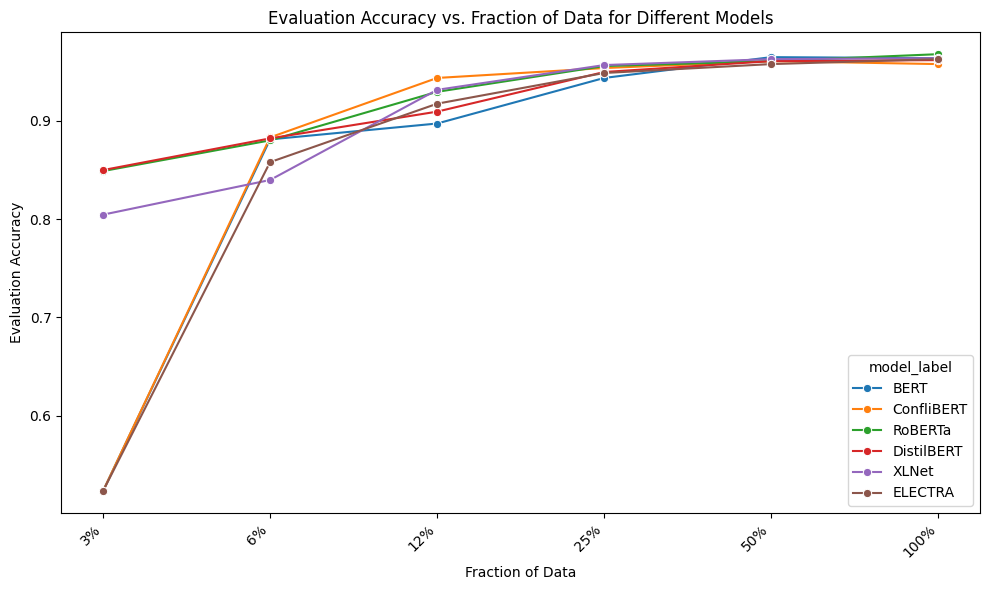

In [22]:
# prompt: fraction_label on x axis, eval_accuracy on y axis and model_label as legends for lines with different colors

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'final_results_df' is your DataFrame
# Create the plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="fraction_label", y="eval_accuracy", hue="model_label", marker="o")

# Customize the plot
plt.xlabel("Fraction of Data")
plt.ylabel("Evaluation Accuracy")
plt.title("Evaluation Accuracy vs. Fraction of Data for Different Models")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

def scatter_plot_accuracy_vs_speed(results_df):
    """
    Creates a scatter (bubble) plot showing:
      - X-axis: eval_samples_per_second (throughput)
      - Y-axis: eval_accuracy
      - Color by model_label (hue)
      - Bubble size by fraction_raw (size)

    Assumes results_df has columns:
      - 'eval_samples_per_second'
      - 'eval_accuracy'
      - 'model_label' (string)
      - 'fraction_raw' (numeric, e.g. 0.03125, 0.0625, etc.)
    """

    # Initialize figure
    plt.figure(figsize=(8, 6))

    # Create scatterplot with Seaborn
    scatter = sns.scatterplot(
        data=results_df,
        x="eval_samples_per_second",
        y="eval_accuracy",
        hue="model_label",         # color by model
        size="fraction_raw",       # size by fraction (bubble size)
        sizes=(20, 400),          # min to max size of markers (tweak as needed)
        alpha=0.7                 # partial transparency
    )

    # Labeling
    scatter.set_title("Accuracy vs. Throughput (Samples/Sec)")
    scatter.set_xlabel("Throughput (eval_samples_per_second)")
    scatter.set_ylabel("Accuracy")

    # (Optional) Move legend to a less intrusive location
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

    # Show the plot
    plt.tight_layout()
    plt.show()


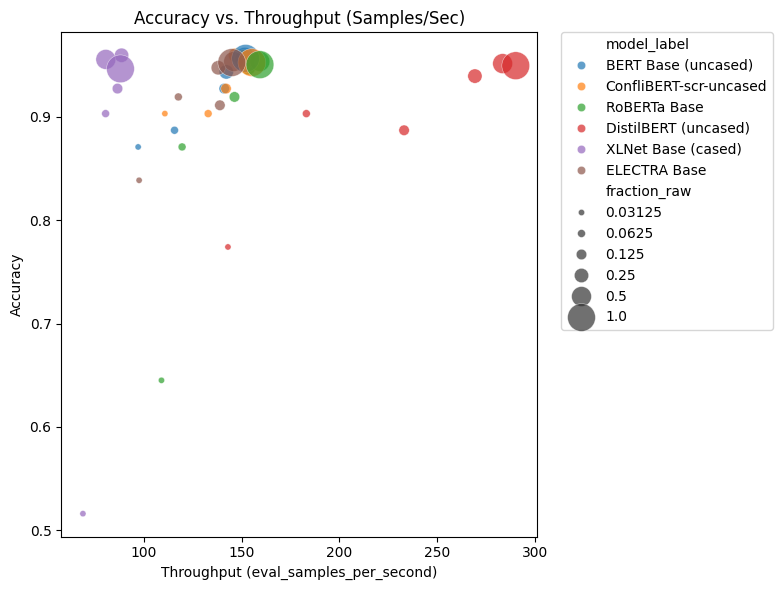

In [ ]:
scatter_plot_accuracy_vs_speed(df)

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_heatmap(results_df, value):
    """
    Creates a heatmap where:
      - Rows = Models (model_label)
      - Columns = Fractions (fraction_label)
      - Cell Values = eval_accuracy (color-coded)
    """

    # 1. Pivot the DataFrame: index=Model, columns=Fraction, values=Accuracy
    heatmap_data = results_df.pivot(
        index="model_label",
        columns="fraction_label",
        values= value
    )

    # 2. Sort columns in ascending order of fraction if you want
    heatmap_data = heatmap_data[["3%", "6%", "12%", "25%", "50%", "100%"]]

    # 3. Create the heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        heatmap_data,
        annot=True,         # writes the accuracy values in each cell
        fmt=".3f",          # format for floating point
        cmap="YlGnBu",      # color palette
        cbar_kws={"label": "Accuracy"}  # colorbar label
    )

    # 4. Labeling and layout
    plt.title(f"{value} by Model and Data Fraction")
    plt.xlabel("Data Fraction")
    plt.ylabel("Model")
    plt.tight_layout()
    plt.show()


In [25]:
plot_heatmap(df, "eval_f1_macro")

KeyError: 'eval_f1_macro'

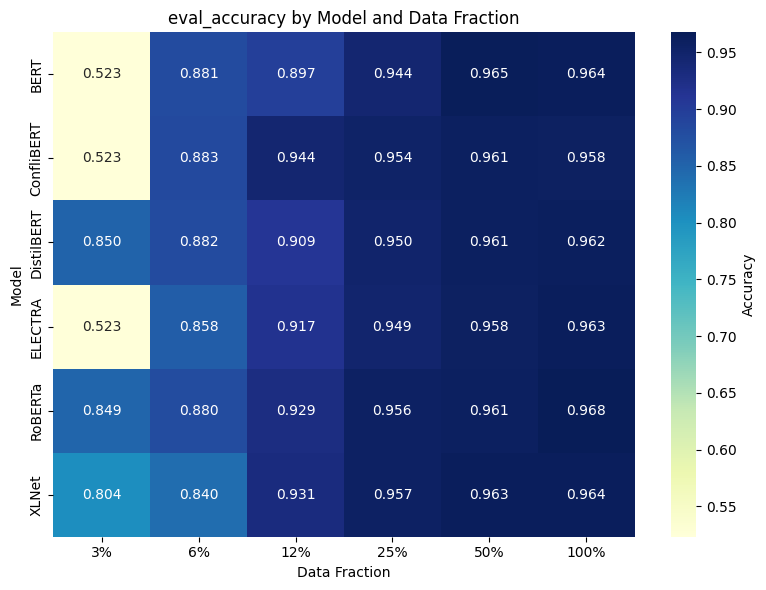

In [26]:
plot_heatmap(df, "eval_accuracy") # Change plot_heatmap_accuracy to plot_heatmap

In [27]:
plot_heatmap(df, "eval_f1_weighted") # Change plot_heatmap_accuracy to plot_heatmap

KeyError: 'eval_f1_weighted'